In [6]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parents[1]))

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from src.training.train import load_and_prepare_data
from src.training.train_mlp import split_train_val_test
from src.utils.config import (
    MLP_VAL_SIZE,
    OPERATIONAL_THRESHOLD,
    RANDOM_STATE,
    TEST_SIZE,
    get_models_dir,
)

# Configuração visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f'Threshold operacional: {OPERATIONAL_THRESHOLD}')
print(f'Random state: {RANDOM_STATE}')

Threshold operacional: 0.11
Random state: 42


In [7]:
# carrega dataset
X, y = load_and_prepare_data()

# split 70/15/15
X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(
    X, y,
    test_size=TEST_SIZE * 0.75,
    val_size=MLP_VAL_SIZE,
    random_state=RANDOM_STATE,
)

print(f'Tamanho do test set: {len(X_test)} clientes')
print(f'Churn rate no test set: {y_test.mean():.2%}')

2026-04-26 17:44:45,064 - INFO - Carregando dataset de C:\Users\gfrei\Documents\1. FIAP\3. FASE1\9. TECH_CHALLENGE\tech-challenge-fase01\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv
2026-04-26 17:44:45,212 - INFO - Dados carregados com sucesso: 7043 linhas, 21 colunas
2026-04-26 17:44:45,213 - INFO - Limpando dados (sem cálculo de estatísticas globais)...
2026-04-26 17:44:45,230 - INFO - Coluna 'TotalCharges' convertida para numérico; 11 valores coagidos para NaN.
2026-04-26 17:44:45,245 - INFO - Coluna 'TotalCharges': 11 valores nulos (0.16%) -- serão tratados no pipeline sklearn.
2026-04-26 17:44:45,280 - INFO - Nenhum registro duplicado encontrado.
2026-04-26 17:44:45,291 - INFO - Limpeza concluída: 7043 linhas, 21 colunas, 11 valores nulos restantes (tratados no pipeline)
2026-04-26 17:44:45,293 - INFO - Aplicando feature engineering...
2026-04-26 17:44:45,295 - INFO - Colunas 'Partner' e 'Dependents' encontradas. Criando 'FamilyStatus'.
2026-04-26 17:44:45,379 - INFO - Variável '

Tamanho do test set: 1057 clientes
Churn rate no test set: 26.49%


In [10]:
# Configura MLflow para carregar modelo do Registry (stage Production)
mlflow.set_tracking_uri('sqlite:///../../mlflow.db')

# Carrega preprocessor (não está no Registry, está em models/)
preprocessor = joblib.load(get_models_dir() / 'mlp_preprocessor.pkl')

# Aplica preprocessor no test set
X_test_prep = preprocessor.transform(X_test)
print(f'Shape após preprocessing: {X_test_prep.shape}')

# Carrega MLP do MLflow Registry
mlp_model = mlflow.pytorch.load_model(
    'models:/mlp_pytorch/Production',
    map_location='cpu'
)
mlp_model.eval()

print('Modelo MLP carregado do MLflow Registry')

Shape após preprocessing: (1057, 60)
Modelo MLP carregado do MLflow Registry


In [11]:
# gera as probas
with torch.no_grad():
    X_tensor = torch.from_numpy(X_test_prep.astype(np.float32))
    logits = mlp_model(X_tensor)
    probas = torch.sigmoid(logits).numpy().ravel()

# Aplica threshold
y_pred = (probas > OPERATIONAL_THRESHOLD).astype(int)

print(f'Predições geradas: {len(probas)}')
print(f'Probabilidade média: {probas.mean():.3f}')
print(f'Taxa flagada (threshold {OPERATIONAL_THRESHOLD}): {y_pred.mean():.2%}')

Predições geradas: 1057
Probabilidade média: 0.416
Taxa flagada (threshold 0.11): 76.73%


In [12]:
def metrics_by_subgroup(
    X_test: pd.DataFrame,
    y_true: np.ndarray,
    y_proba: np.ndarray,
    y_pred: np.ndarray,
    sensitive_feature: str,
) -> pd.DataFrame:
    """Calcula métricas de performance desagregadas por valores da feature sensível."""
    rows = []
    
    for value in sorted(X_test[sensitive_feature].unique()):
        mask = (X_test[sensitive_feature] == value).values
        n = int(mask.sum())
        
        if n == 0:
            continue

        y_true_sub = y_true[mask]
        y_proba_sub = y_proba[mask]
        y_pred_sub = y_pred[mask]
        
        # Churn rate real do subgrupo
        churn_rate = float(y_true_sub.mean())

        # ROC-AUC só faz sentido se houver ambas as classes
        if len(np.unique(y_true_sub)) > 1:
            auc = roc_auc_score(y_true_sub, y_proba_sub)
        else:
            auc = np.nan

        rows.append({
            'subgroup': f'{sensitive_feature} = {value}',
            'n': n,
            'churn_rate_real': churn_rate,
            'roc_auc': auc,
            'recall': recall_score(y_true_sub, y_pred_sub, zero_division=0),
            'precision': precision_score(y_true_sub, y_pred_sub, zero_division=0),
            'f1': f1_score(y_true_sub, y_pred_sub, zero_division=0),
            'flagged_rate': float(y_pred_sub.mean()),
        })
    
    return pd.DataFrame(rows)

In [13]:
metrics_gender = metrics_by_subgroup(
    X_test, y_test.values, probas, y_pred, 'gender'
)
metrics_gender.round(4)

,subgroup,n,churn_rate_real,roc_auc,recall,precision,f1,flagged_rate
0,gender = Female,529,0.2703,0.8451,1.0,0.3505,0.5191,0.7713
1,gender = Male,528,0.2595,0.8495,1.0,0.3400,0.5074,0.7633


In [14]:
# Calcula gaps (diferença entre maior e menor valor)
gaps_gender = {
    'roc_auc_gap': metrics_gender['roc_auc'].max() - metrics_gender['roc_auc'].min(),
    'recall_gap': metrics_gender['recall'].max() - metrics_gender['recall'].min(),
    'precision_gap': metrics_gender['precision'].max() - metrics_gender['precision'].min(),
}

print('Disparidades por gender:')
for metric, gap in gaps_gender.items():
    flag = '🟢' if gap < 0.03 else ('🟡' if gap < 0.05 else '🔴')
    print(f'  {flag} {metric}: {gap:.4f} ({gap*100:.2f}pp)')

Disparidades por gender:
  🟢 roc_auc_gap: 0.0044 (0.44pp)
  🟢 recall_gap: 0.0000 (0.00pp)
  🟢 precision_gap: 0.0105 (1.05pp)


In [15]:
metrics_senior = metrics_by_subgroup(
    X_test, y_test.values, probas, y_pred, 'SeniorCitizen'
)
metrics_senior.round(4)

,subgroup,n,churn_rate_real,roc_auc,recall,precision,f1,flagged_rate
0,SeniorCitizen = 0,888,0.2309,0.8507,1.0,0.3159,0.4801,0.7309
1,SeniorCitizen = 1,169,0.4438,0.7699,1.0,0.4630,0.6329,0.9586


In [16]:
gaps_senior = {
    'roc_auc_gap': metrics_senior['roc_auc'].max() - metrics_senior['roc_auc'].min(),
    'recall_gap': metrics_senior['recall'].max() - metrics_senior['recall'].min(),
    'precision_gap': metrics_senior['precision'].max() - metrics_senior['precision'].min(),
}

print('Disparidades por SeniorCitizen:')
for metric, gap in gaps_senior.items():
    flag = '🟢' if gap < 0.03 else ('🟡' if gap < 0.05 else '🔴')
    print(f'  {flag} {metric}: {gap:.4f} ({gap*100:.2f}pp)')

Disparidades por SeniorCitizen:
  🔴 roc_auc_gap: 0.0807 (8.07pp)
  🟢 recall_gap: 0.0000 (0.00pp)
  🔴 precision_gap: 0.1471 (14.71pp)


In [17]:
X_test_with_combo = X_test.copy()
X_test_with_combo['gender_x_senior'] = (
    X_test['gender'].astype(str) + '_senior=' + X_test['SeniorCitizen'].astype(str)
)

metrics_intersect = metrics_by_subgroup(
    X_test_with_combo, y_test.values, probas, y_pred, 'gender_x_senior'
)
metrics_intersect.round(4)

,subgroup,n,churn_rate_real,roc_auc,recall,precision,f1,flagged_rate
0,gender_x_senior = Female_senior=0,441,0.2381,0.8528,1.0,0.3261,0.4918,0.7302
1,gender_x_senior = Female_senior=1,88,0.4318,0.7595,1.0,0.4419,0.6129,0.9773
2,gender_x_senior = Male_senior=0,447,0.2237,0.8487,1.0,0.3058,0.4684,0.7315
3,gender_x_senior = Male_senior=1,81,0.4568,0.7844,1.0,0.4868,0.6549,0.9383


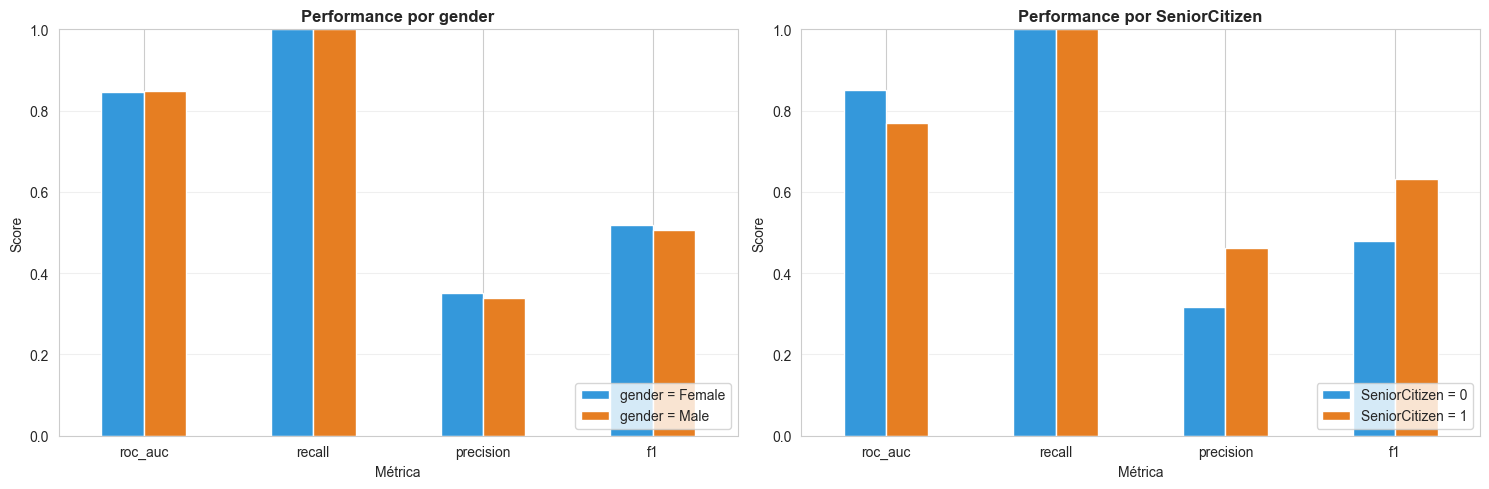

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
metrics_to_plot = ['roc_auc', 'recall', 'precision', 'f1']
df_plot = metrics_gender[['subgroup'] + metrics_to_plot].set_index('subgroup').T
df_plot.plot(kind='bar', ax=ax, rot=0, color=['#3498db', '#e67e22'])
ax.set_title('Performance por gender', fontsize=12, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Métrica')
ax.set_ylim(0, 1.0)
ax.legend(title='', loc='lower right')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
df_plot = metrics_senior[['subgroup'] + metrics_to_plot].set_index('subgroup').T
df_plot.plot(kind='bar', ax=ax, rot=0, color=['#3498db', '#e67e22'])
ax.set_title('Performance por SeniorCitizen', fontsize=12, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Métrica')
ax.set_ylim(0, 1.0)
ax.legend(title='', loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../../docs/fairness_by_subgroup.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
print('=== Demographic Parity por gender ===')
for _, row in metrics_gender.iterrows():
    print(f"  {row['subgroup']}:")
    print(f"    Churn rate real:  {row['churn_rate_real']:.2%}")
    print(f"    Taxa flagada:     {row['flagged_rate']:.2%}")
    print(f"    Recall (capturados): {row['recall']:.2%}")
    print()

print('=== Demographic Parity por SeniorCitizen ===')
for _, row in metrics_senior.iterrows():
    print(f"  {row['subgroup']}:")
    print(f"    Churn rate real:  {row['churn_rate_real']:.2%}")
    print(f"    Taxa flagada:     {row['flagged_rate']:.2%}")
    print(f"    Recall (capturados): {row['recall']:.2%}")
    print()

=== Demographic Parity por gender ===
  gender = Female:
    Churn rate real:  27.03%
    Taxa flagada:     77.13%
    Recall (capturados): 100.00%

  gender = Male:
    Churn rate real:  25.95%
    Taxa flagada:     76.33%
    Recall (capturados): 100.00%

=== Demographic Parity por SeniorCitizen ===
  SeniorCitizen = 0:
    Churn rate real:  23.09%
    Taxa flagada:     73.09%
    Recall (capturados): 100.00%

  SeniorCitizen = 1:
    Churn rate real:  44.38%
    Taxa flagada:     95.86%
    Recall (capturados): 100.00%

